### 1.0 Building the article corpus

We need data our model can learn from. The goal is to pull one year of Tesla news from Finnhub using the `company_news` endpoint and save it as a raw corpus. One year is as far back as Finnhub's free tier lets us go.

**Output:** `raw_articles.parquet`

In [15]:
import finnhub
from news_sentiment.config import FINNHUB_API_KEY

finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)

#### 1.1 Timestamps: convert to UTC and guard it
Finnhub gives each article's publication time as a **unix timestamp**, the number of seconds since 1 January 1970. We turn this into a real datetime before storing it.

The default conversion (`datetime.fromtimestamp(ts)`) uses the **local** timezone of the machine, which shifts the time by our own offset. We pass `tz=timezone.utc` so every article time is set to one standard zone, UTC. This matters because the timestamp is the key we use to line up articles with market data. If it is off by even a few hours, an article gets matched to the wrong market move and the model learns from wrong labels, and no error is ever raised. So we keep every timestamp in UTC across the whole pipeline.

In [16]:
from datetime import datetime, timezone


def to_utc(ts):
    """Convert a unix timestamp (seconds) to a timezone-aware UTC datetime."""
    return datetime.fromtimestamp(ts, tz=timezone.utc)

#### 1.2 Pulling month by month, within the rate limit
`company_news` takes a date range but only returns a **limited** number of articles per call, so a single two-year request would quietly cut some off. Instead we split the range into monthly chunks and make one call per month, so we get the full set.

We also stay within Finnhub's free-tier **limit of 60 calls per minute**. Our range needs about 24 calls, well under the limit. But when we pull more data later, we will need a `time.sleep()` between calls so a burst of requests does not go over.

In [17]:
import time

import pandas as pd


def pull_company_news(ticker, _from, to, pause=0):
    """Pull company news month by month and return it as a DataFrame.

    ticker: symbol to query, e.g. "TSLA".
    _from, to: inclusive date bounds as 'YYYY-MM-DD' strings.
    pause: seconds to sleep between calls, keeping us under 60 calls/min.
    """
    rows = []
    start = pd.Timestamp(_from)
    end = pd.Timestamp(to)

    while start <= end:
        # Last day of the current month, or the overall end if it comes first.
        month_end = min(start + pd.offsets.MonthEnd(0), end)

        articles = finnhub_client.company_news(
            ticker,
            _from=start.strftime("%Y-%m-%d"),
            to=month_end.strftime("%Y-%m-%d"),
        )
        for a in articles:
            rows.append(
                {
                    "article_id" : a["id"],
                    "headline": a["headline"],
                    "summary": a["summary"],
                    "source": a["source"],
                    "url": a["url"],
                    "timestamp_utc": to_utc(a["datetime"]),
                }
            )

        start = month_end + pd.Timedelta(days=1)
        time.sleep(pause)

    return pd.DataFrame(rows)

#### 1.3 Decision gate
Once the pull finishes, we count the articles. If we have fewer than ~1,500, the corpus is too small to train on well, and we switch to another source (for example FNSPID or a Kaggle financial-news dataset).

In [18]:
# Pull articles from Finnhub
articles = pull_company_news("TSLA", "2025-07-07", "2026-08-07")

print(articles.count())

article_id       3143
headline         3143
summary          3143
source           3143
url              3143
timestamp_utc    3143
dtype: int64


Our pull returned **3143 articles**, roughly **2x** the threshold, so Finnhub works well as our main source. This number is from the pull at the time of writing; the exact count changes a little each time we pull.

##### Finnhub and Kaggle work well together

The main TSLA news dataset on Kaggle is the "2022 Tesla & Elon Musk Financial News Dataset". It stops around 2022 and holds about 1,500 articles. For recent news Finnhub is clearly better: more articles, up to date, and we can pull it again whenever we want. But the one year limit changes how we see the older datasets. Because Finnhub cannot return anything older than about a year, the 2022 Kaggle set holds articles Finnhub will never give us. Those older articles could be very useful if we later want a longer training history. They extend the timeline back, and since their dates do not overlap with our Finnhub window, there is nothing to remove as duplicates. For now Finnhub on its own is enough, and we keep Kaggle in reserve to fill in earlier years.

## 2. Exploratory data analysis
Before moving on, it is worth looking at the raw corpus to see what kind of data we have, whether it is usable, and whether it needs any cleaning. We look at how articles are spread over time, which sources appear most, when articles are published, how long their summaries are, and whether any fields are missing or duplicated.

#### 2.1 Article volume by month
Counting articles per month shows how well the year is covered. Ideally we want a fairly even spread, with no gaps in the data. Small drops or spikes are fine, and even welcome, since they line up with quiet periods or busy news events such as earnings.

C:\Users\adamw\AppData\Local\Temp\ipykernel_92928\2844731141.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = articles["timestamp_utc"].dt.to_period("M").value_counts().sort_index()


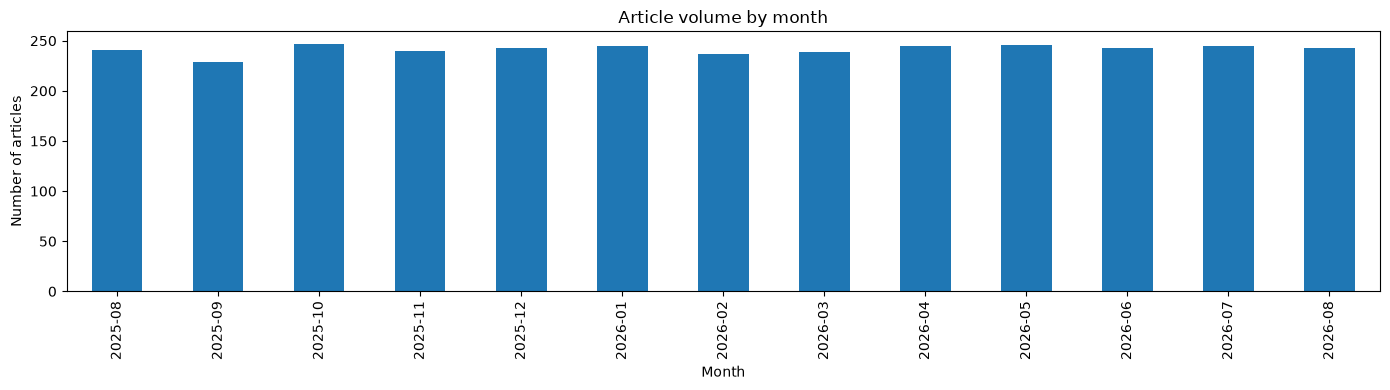

In [19]:
import matplotlib.pyplot as plt

monthly = articles["timestamp_utc"].dt.to_period("M").value_counts().sort_index()

ax = monthly.plot(kind="bar", figsize=(14, 4))
ax.set_title("Article volume by month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of articles")
plt.tight_layout()
plt.show()

No large drops or spikes: the corpus has a good, fairly even spread across the months.

#### 2.2 Duplicate headlines
News outlets often run the same story, so the same headline can appear many times. Duplicates add to our counts, so we measure how many there are and look at the worst offenders.

In [20]:
dup_count = articles["headline"].duplicated().sum()
print(f"Duplicate headlines: {dup_count} of {len(articles)} ({dup_count / len(articles):.1%})")

articles["headline"].value_counts().head(10)

Duplicate headlines: 36 of 3143 (1.1%)


headline
10 Consumer Discretionary Stocks With Whale Alerts In Today's Session         9
10 Consumer Discretionary Stocks Whale Activity In Today's Session            5
Why Tesla (TSLA) Shares Are Trading Lower Today                               3
Tesla, Inc. (TSLA) Is a Trending Stock: Facts to Know Before Betting on It    3
Assessing Tesla's Performance Against Competitors In Automobiles Industry     3
Comparative Study: Tesla And Industry Competitors In Automobiles Industry     3
BC-Most Active Stocks                                                         2
5 Things to Know Before the Stock Market Opens                                2
Auto & Transport Roundup: Market Talk                                         2
Is Rivian Stock a Buy Now?                                                    2
Name: count, dtype: int64

Only 1.1% of the corpus is duplicate headlines, which is nice and low. We note it here and will remove the duplicates before scoring, but we lose so few articles that the corpus is barely affected.

#### 2.3 Top 15 sources
The mix of sources tells us whether the corpus leans on just a few outlets. If one publisher dominates, its tone can seep into our sentiment features and bias them.

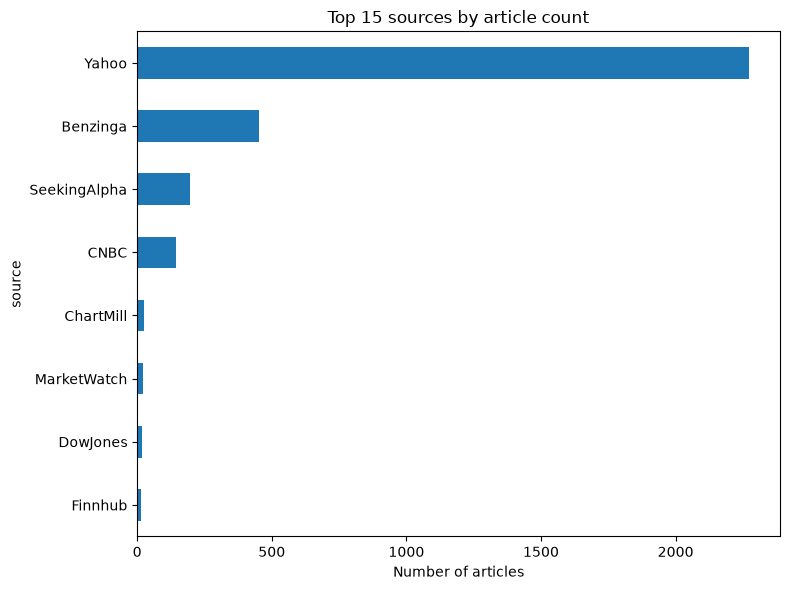

In [21]:
top_sources = articles["source"].value_counts().head(15)

ax = top_sources.plot(kind="barh", figsize=(8, 6))
ax.set_title("Top 15 sources by article count")
ax.set_xlabel("Number of articles")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The corpus comes from very few sources. Only 8 outlets appear, and one of them, Yahoo, makes up 72% of all articles, with the top five covering 98%. This is a real limitation. Yahoo is a website that reposts other outlets' stories under its own name, so the label hides who actually wrote the piece, and any bias in what Yahoo covers or how it words things carries into most of the corpus. One idea worth trying is to follow each article's url and read its HTML page, which could tell us the real publisher, but more on that later.

#### 2.4 Volume by day of week
Articles tend to bunch up on weekdays, when markets are open and companies release news. A strong weekday lean is expected, and it shows the corpus follows trading activity rather than random noise.

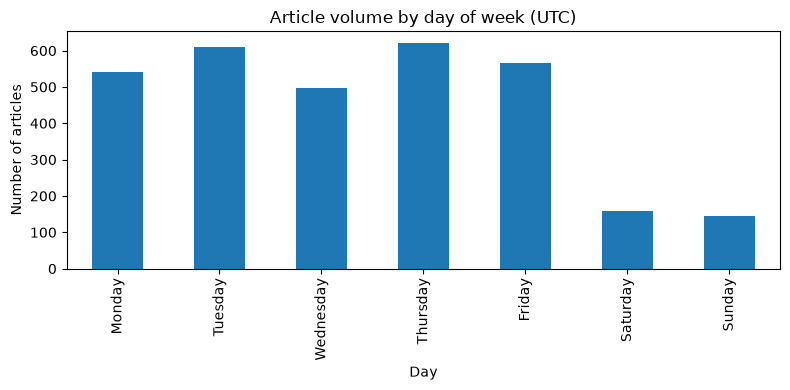

In [22]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = articles["timestamp_utc"].dt.day_name().value_counts().reindex(order)

ax = dow_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Article volume by day of week (UTC)")
ax.set_xlabel("Day")
ax.set_ylabel("Number of articles")
plt.tight_layout()
plt.show()

As expected, article volume leans heavily towards weekdays.

#### 2.5 Volume by hour of day
Hours are in UTC and run from 0 to 23. The time an article is published matters for how we match it to a market return: an article published before the open lines up with a different trading session than one published in the afternoon.

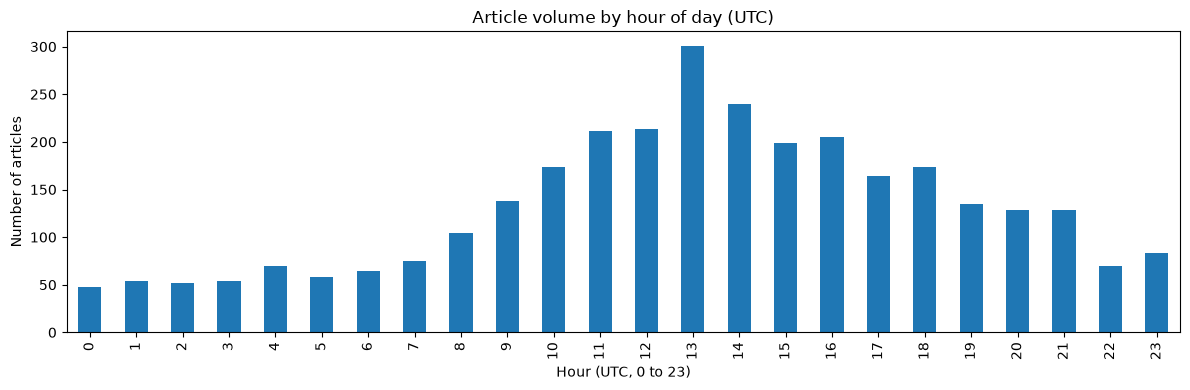

In [23]:
hour_counts = articles["timestamp_utc"].dt.hour.value_counts().reindex(range(24), fill_value=0).sort_index()

ax = hour_counts.plot(kind="bar", figsize=(12, 4))
ax.set_title("Article volume by hour of day (UTC)")
ax.set_xlabel("Hour (UTC, 0 to 23)")
ax.set_ylabel("Number of articles")
plt.tight_layout()
plt.show()

Early afternoon UTC hours stand out, with a clear spike around 13:00. That is the **US market open** (9:30 ET is 13:30 UTC in summer): news pours in as soon as trading starts, reporting the day's new stories right away.

#### 2.6 Empty or missing fields
Finnhub sometimes returns a blank summary or source. We count empty and missing values per column so we can decide, before scoring, whether to drop those rows or fetch from URL.

In [24]:
for col in ["headline", "summary", "source", "url"]:
    empty = (articles[col].isna() | (articles[col].str.strip() == "")).sum()
    print(f"{col}: {empty} empty or missing ({empty / len(articles):.1%})")

print(f"timestamp_utc: {articles['timestamp_utc'].isna().sum()} missing")

headline: 0 empty or missing (0.0%)
summary: 76 empty or missing (2.4%)
source: 0 empty or missing (0.0%)
url: 0 empty or missing (0.0%)
timestamp_utc: 0 missing


76 summaries are missing, again a small share at only 2.4%. Still, the summary is probably our most important field after the url. Instead of falling back to the headline for these rows, we will either drop them or fetch the full article from its url, which we come back to later in the notebook.

#### 2.7 Summary length
The summary holds most of each article's text, so its length is what the 512 token limit will act on during scoring. Measuring it now shows whether summaries fit in one pass or need cutting down, and it shows which rows have an empty summary and only a headline.

Summary length in characters: mean 206.3, median 144
Summary length in words: mean 32.8, median 23


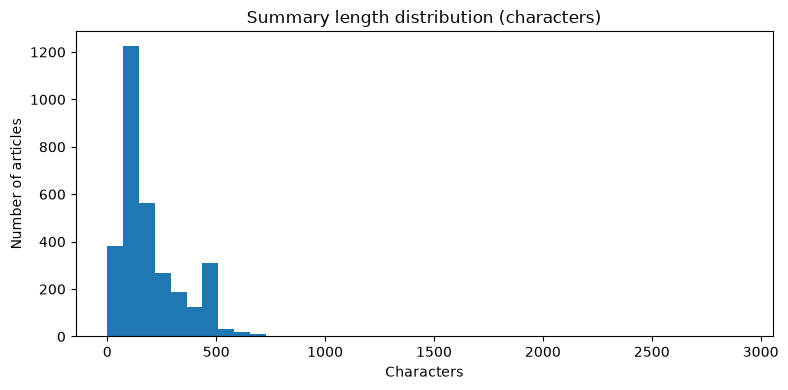

In [25]:
summary_chars = articles["summary"].str.len()
summary_words = articles["summary"].str.split().str.len()

print(f"Summary length in characters: mean {summary_chars.mean():.1f}, median {summary_chars.median():.0f}")
print(f"Summary length in words: mean {summary_words.mean():.1f}, median {summary_words.median():.0f}")

ax = summary_chars.plot(kind="hist", bins=40, figsize=(8, 4))
ax.set_title("Summary length distribution (characters)")
ax.set_xlabel("Characters")
ax.set_ylabel("Number of articles")
plt.tight_layout()
plt.show()

A rough English conversion is **1 token ≈ 4 characters**. So a 206-character summary is about **50 tokens**, roughly **10%** of the 512 token limit, so summaries fit easily in a single FinBERT pass with no cutting. One thing to note: a short summary may not hold enough of the article to judge it fully, which we come back to later in the notebook.

#### 2.8 Top words in headlines
Counting the most common headline words is a quick check that the corpus is really about the target company: words like Tesla and Musk should be at the top. It also gives an early, rough feel for the themes, which the topic modelling stage will pin down later. A short stopword list drops common filler words so the ranking shows content, not grammar.

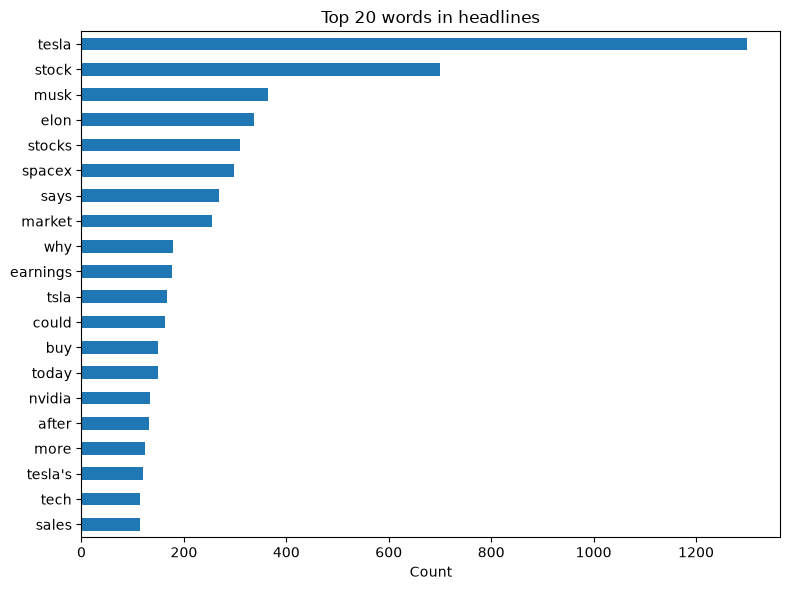

In [26]:
import re
from collections import Counter

stopwords = {
    "the", "a", "an", "to", "of", "in", "on", "for", "and", "is", "as", "at",
    "by", "with", "from", "its", "it", "this", "that", "are", "be", "will",
}

counts = Counter()
for headline in articles["headline"].dropna():
    counts.update(re.findall(r"[a-z']{3,}", headline.lower()))

top_words = pd.Series(
    {word: n for word, n in counts.most_common() if word not in stopwords}
).head(20)

ax = top_words.plot(kind="barh", figsize=(8, 6))
ax.set_title("Top 20 words in headlines")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

As expected, 'tesla' is at the top, with 'stock' and 'elon' close behind, which shows the corpus is about the right subject. More interesting is that 'nvidia' reaches the top 15. This hints that some articles carry sentiment aimed at other companies, not Tesla, which could throw off the overall sentiment. Keeping that out is exactly the job of the entity filtering stage.

#### 2.9 Busiest days
The days with the most articles are usually big event days such as earnings, product launches, or recalls. These spikes are where the strongest market reactions happen, so knowing when they occur hints at where the labels will carry the most signal. We list the ten busiest days and plot daily volume to see how the spikes stand out from the normal level.

Ten busiest days:
timestamp_utc
2026-01-29    132
2026-04-27     75
2026-01-30     68
2025-10-27     67
2026-06-29     67
2026-07-28     67
2026-03-27     64
2026-07-30     64
2026-08-05     63
2026-06-30     62


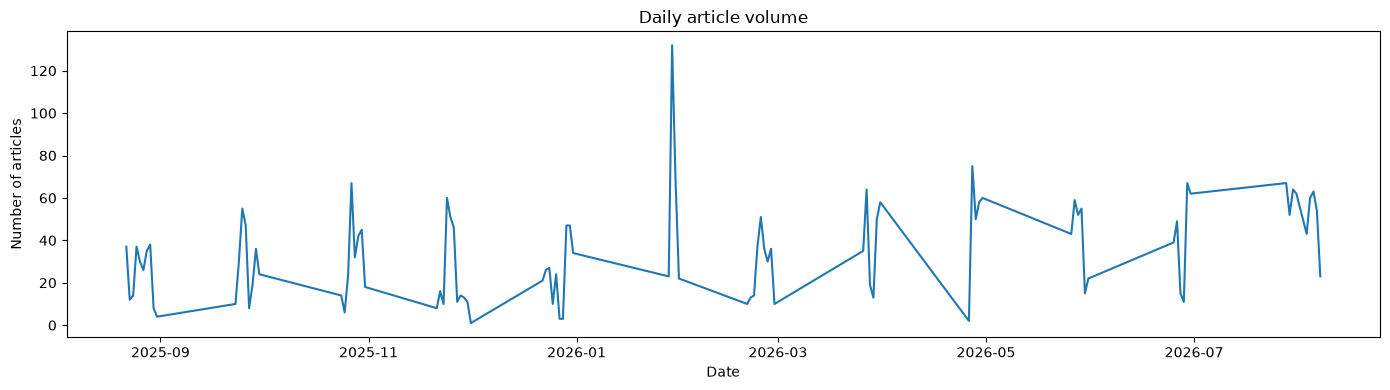

In [27]:
daily = articles["timestamp_utc"].dt.date.value_counts()

print("Ten busiest days:")
print(daily.head(10).to_string())

daily_sorted = daily.sort_index()
ax = daily_sorted.plot(kind="line", figsize=(14, 4))
ax.set_title("Daily article volume")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
plt.tight_layout()
plt.show()

## 3. A closer look: what kind of articles are these?

The EDA so far tells us how many articles we have and when they arrive, but not what they are about. Before scoring them for sentiment, it helps to know what kind of writing the corpus holds. The first question is a simple one: are these articles just reacting to the stock's price moves, or are they reporting genuine company news?

The difference matters for sentiment. An article that only says the share price fell carries little about Tesla itself, and its tone tends to mirror the very move we are trying to predict. An article reporting a real event, such as a recall, an earnings beat, or a new factory, carries fresh information that could drive the next move. A corpus made mostly of price-reaction pieces would give the model a weak, backward looking signal.

Rather than jump straight to code, we start by eye. We pull a random sample of about 20 articles and read their headline and summary, just to get a feel for the mix before we try to measure it. A fixed random seed keeps the sample the same each run.

In [ ]:
import pandas as pd
from news_sentiment.config import RAW_DATA_DIR

# Load the articles
articles = pd.read_parquet(RAW_DATA_DIR / "raw_articles.parquet")
sample = articles.sample(20, random_state=42)

for _, row in sample.iterrows():
    print(row["headline"])
    print(row["summary"])
    print()

Reading through the sample is encouraging. Most articles report genuine company news, deliveries, product plans, legal action, and the like, rather than just narrating the day's price move. Real information about Tesla is clearly present in the text, which is exactly what the sentiment model needs to work with. A few pieces are pure market reaction or mention Tesla only in passing, but they look to be the minority. That is a good enough signal to move on for now; a proper keyword or model based split can wait until we know we actually need it.

## 4. Current limitations from the data

The analysis brought up three limitations in the raw corpus that could hold back the model. None breaks the pipeline, but all are worth stating clearly and coming back to.

### Short summaries

The Finnhub `company_news` endpoint gives us only a short summary per article, around 50 tokens on average. That fits easily inside a single FinBERT pass, but a short summary may not hold enough of the article to judge its market impact well. If it leaves out the detail that actually moved the stock, the model is left learning from a weak signal.

### The true source is hidden

The corpus comes from only 8 outlets, and one of them, Yahoo, makes up 72% of all articles. Yahoo is a website that reposts other outlets' stories under its own name, so the `source` label rarely tells us who actually wrote the piece. This means we cannot reliably tie articles to the outlet that wrote them, which limits any look at the true sources or checks for bias.

### The publication time may be off

The same repost problem raises a possible concern about the timestamp. Since most articles reach us through an aggregator like Yahoo, the time Finnhub gives could be when the piece was reposted rather than when the original outlet first published it. If that is the case, a repost can lag the original by minutes or hours, so the time we store might sit some way after the real publication. We have not confirmed this happens, but if it does it matters, because we use the timestamp to line each article up with a market move, and a shifted time could tie an article to the wrong trading session. It is reason enough to treat any time-of-day analysis with caution for now.

### A possible fix: fetch the article HTML

All three problems could be eased by the same step: following each article's `url` and fetching the page's HTML. From that we could pull the full article body, far more text than the summary, read the real publisher from the page's byline or page details, and read the original publication time from the page. One step, three wins.

### Why it is not simple

Fetching thousands of live web pages runs into real problems:

1. Consent and cookie walls, especially on Yahoo, may return a blocking page instead of the article. Since Yahoo is 72% of the corpus, this alone could sink our coverage.
2. Many pages load their body with JavaScript after the page opens, so a simple fetch of the raw HTML may not hold the article text at all, and getting it would need a headless browser.
3. Some outlets, such as SeekingAlpha, MarketWatch, and DowJones, put their full text behind a paywall, so even a successful fetch may return only a short preview.
4. Page layout differs from site to site, so pulling clean body text easily breaks and has to be handled site by site.
5. With thousands of requests, sites slow down or block fast bursts, so we have to space the calls out and it takes time, and some will still fail, leaving gaps in coverage.

### A route worth investigating

Fetching the article HTML is a promising idea: it could give us the full body, the true publisher, and the original publication time, easing all three limitations in one step. The problems above mean it is not sure to work, so it is worth testing rather than assuming. We note it here as a direction worth looking into.

## 5. Saving the raw corpus

This wraps up the corpus-building notebook. We set out to pull a year of Tesla news from Finnhub and check it was good enough to build on, and that worked out. The `company_news` endpoint returned over 3,000 articles across the year, comfortably past the threshold we set, so Finnhub stands as our main source.

We then ran a basic round of EDA as a sanity check, not a deep study, just enough to trust the data before moving on. The corpus is spread fairly evenly across the months, leans to weekdays and US trading hours as expected, carries very few duplicates or missing fields, and reads mostly as genuine company news rather than pure price reaction. In short, the articles look useful for the sentiment work ahead.

The EDA also surfaced three limitations to keep in mind: short summaries, a hidden true source, and timestamps that may reflect a repost rather than the original publication. None blocks us now, and all three could be eased later by fetching the article HTML, which we flag as a route worth investigating.

With that settled, we save the corpus to `raw_articles.parquet` in its current, raw state, before any cleaning or extra processing. Later stages read from this file instead of calling the API again, so the pull can be repeated and Finnhub is only called once. Further EDA and feature work continue in a separate notebook.

In [28]:
from news_sentiment.config import RAW_DATA_DIR

output_path = RAW_DATA_DIR / "raw_articles.parquet"
articles.to_parquet(output_path, index=False)

print(f"Saved {len(articles)} articles to {output_path}")

Saved 3143 articles to C:\Users\adamw\programming-projects\Python\stock-predictor\data\raw\raw_articles.parquet
